# Day 14: Geleneksel Öznitelik Çıkarımı (ORB, SIFT, GLCM) & Jakarlı Halı Desen Sınıflandırması

**Aşama:** Faz 2: Endüstriyel Görüntü İşleme (Day 14)  
**Konu:** ORB ve SIFT Yerel Anahtar Noktaları, GLCM Haralick Doku Analizi, 3D HSV Renk Histogramı, Çok Modlu Öznitelik Füzyonu ve Top-K Görsel Arama  
**Yazar:** Seydi Eryılmaz (@seydivakkas)  
**Telif Hakkı:** (c) 2026 Seydi Eryılmaz. Özel Lisans — Tüm Hakları Saklıdır.

---

## 1. Problem ve Endüstriyel Motivasyon
Merinos halı fabrikalarında dokuma tezgâhlarından çıkan veya numune laboratuvarına gelen jakarlı halıların otomatik kataloglanması, desen sınıflandırması ve kalite teftişi için klasik öznitelik çıkarımı kritik bir ara katmandır.
Yüksek hızda akan dokuma hattında derin öğrenme modellerinin donanım maliyeti ve gecikmesi yerine, hafif ve kararlı yerel anahtar nokta (ORB, SIFT) ve doku/renk betimleyicileri (GLCM, 3D HSV histogramı) kullanılmaktadır.


## 2. ORB (FAST + rBRIEF) Matematiksel Teorisi & Hızlı İkili Tanımlayıcılar

Rublee ve ark. (2011) tarafından patent kısıtı olmayan ve SIFT'e hafif bir alternatif olarak geliştirilen ORB, iki temel bileşenden oluşur:

1. **FAST Köşe Tespiti (Features from Accelerated Segment Test):**
   Merkez piksel $p$ etrafındaki 16 piksellik Bresenham çemberinde, $I_p \pm \epsilon$ eşiğini aşan ardışık $N=9$ piksel varsa köşe kabul edilir.
2. **Yönlendirilmiş FAST (oFAST):**
   Köşenin yön açısı yoğunluk centroidi ile hesaplanır:
   $$m_{pq} = \sum_{x, y} x^p y^q I(x, y), \quad C = \left(\frac{m_{10}}{m_{00}}, \frac{m_{01}}{m_{00}}\right), \quad \theta = \text{atan2}(m_{01}, m_{10})$$
3. **Rotasyona Duyarsız BRIEF (rBRIEF):**
   Seçilen 256 piksel çifti test vektörü $\theta$ açısı kadar döndürülerek 256-bit ikili (binary) tanımlayıcı oluşturulur. Mesafe ölçümü donanımsal XOR ve POPCOUNT ile mikro-saniyeler içinde hesaplanır.


## 3. SIFT (Scale-Invariant Feature Transform) Teorisi

David Lowe (1999, 2004) tarafından geliştirilen SIFT, ölçek ve rotasyona karşı yüksek kararlılık sunar:

1. **Ölçek Uzayı & DoG (Difference-of-Gaussians):**
   $$D(x, y, \sigma) = (G(x, y, k\sigma) - G(x, y, \sigma)) * I(x, y)$$
2. **Uç Nokta Lokalizasyonu:** DoG uzayında 26 komşusuyla karşılaştırılan yerel ekstremumlar tespit edilir, Taylor serisi açılımı ile alt-piksel hassasiyeti sağlanır.
3. **Oryantasyon Ataması:** Gradyan büyüklükleri ve yönleri histogramından baskın yön belirlenir.
4. **128-Boyutlu Tanımlayıcı:** $16 \times 16$ komşuluk, $4 \times 4$'lük 16 alt bölgeye ayrılır ve her bölgede 8 yönlü gradyan histogramı çıkarılır ($16 \times 8 = 128$).


In [1]:
import sys
from pathlib import Path

# Dinamik ve izole proje kök dizini çözümlemesi
CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name.startswith("day") else CURRENT_DIR
DAY14_DIR = PROJECT_ROOT / "day14"
DAY_DIR = DAY14_DIR
project_root = PROJECT_ROOT
root_dir = PROJECT_ROOT
base_dir = PROJECT_ROOT
WORKSPACE_ROOT = PROJECT_ROOT

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Kütüphanelerin Yüklenmesi ve Mini-Proje Modüllerinin İçe Aktarılması
import cv2
import numpy as np
import matplotlib.pyplot as plt

from day14.mini_project.src.keypoint_engine import KeypointFeatureEngine, extract_orb, extract_sift, _to_gray
from day14.mini_project.src.glcm_engine import GLCMFeatureEngine
from day14.mini_project.src.color_histogram import ColorHistogramEngine
from day14.mini_project.src.feature_fusion import CarpetPatternClassifierAndMatcher
from day14.mini_project.src.generator import CarpetPatternFixtureGenerator
from day14.mini_project.src.benchmark import FeatureBenchmarkEngine
from day14.mini_project.src.models import KeypointDescriptorType, PatternClass

OUTPUT_DIR = DAY14_DIR / "mini_project" / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIXTURES_DIR = DAY14_DIR / "mini_project" / "fixtures" / "synthetic_carpets"
FIXTURES_DIR.mkdir(parents=True, exist_ok=True)

print("[OK] Day 14 Öznitelik Çıkarımı Modülleri Başarıyla Yüklendi!")


[OK] Day 14 Öznitelik Çıkarımı Modülleri Başarıyla Yüklendi!


## 4. Örnek sonuçlar: Çıkarılan anahtar noktalar

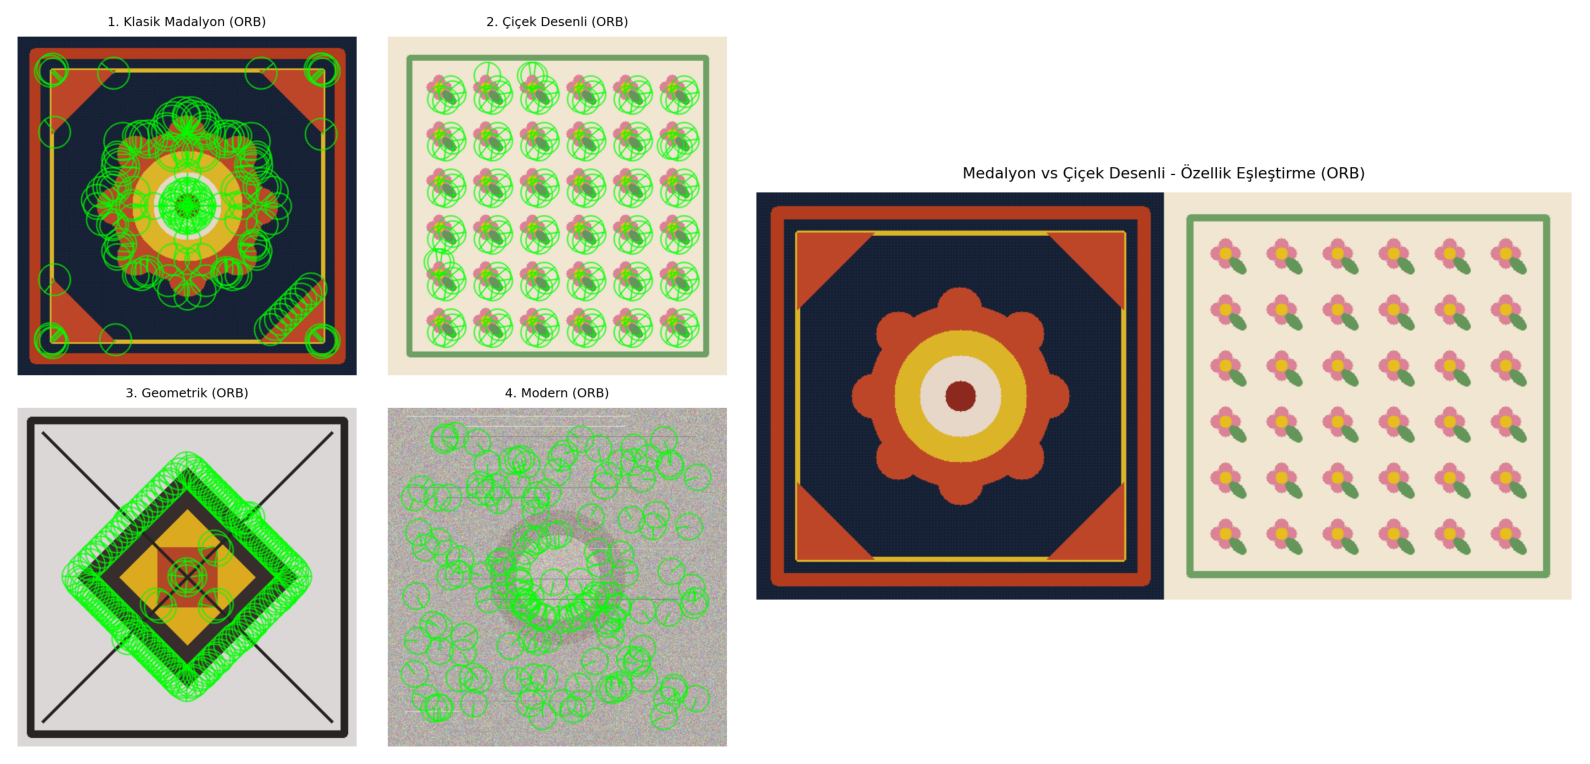

[+] feature_summary_panel.png kaydedildi: C:\Users\seydieryilmaz\Desktop\Projeler\Merinos 40 Günlük Staj Deneyimim\merinos-industrial-ai-internship\day14\mini_project\outputs\feature_summary_panel.png
[+] match_medallion_vs_floral.png kaydedildi: C:\Users\seydieryilmaz\Desktop\Projeler\Merinos 40 Günlük Staj Deneyimim\merinos-industrial-ai-internship\day14\mini_project\outputs\match_medallion_vs_floral.png


In [2]:
# 4. Örnek sonuçlar: Çıkarılan anahtar noktalar ve özellik eşleştirme
gen = CarpetPatternFixtureGenerator(seed=42)
c_med, _ = gen.generate_medallion_classic(400, 400)
c_flo, _ = gen.generate_floral_traditional(400, 400)
c_geo, _ = gen.generate_geometric_modern(400, 400)
c_vin, _ = gen.generate_vintage_distressed(400, 400)

carpets = [
    ("1. Klasik Madalyon (ORB)", c_med),
    ("2. Çiçek Desenli (ORB)", c_flo),
    ("3. Geometrik (ORB)", c_geo),
    ("4. Modern (ORB)", c_vin),
]

# 1. 2x2 Feature Summary Panel
fig_panel, axes_panel = plt.subplots(2, 2, figsize=(10, 10))
for ax, (title, img) in zip(axes_panel.flat, carpets):
    kpts, desc = extract_orb(img, n_features=1000)
    vis = cv2.drawKeypoints(
        img,
        kpts[:150],
        None,
        color=(0, 255, 0),
        flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS,
    )
    ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    ax.set_title(title, fontsize=12, pad=10)
    ax.axis("off")

plt.tight_layout()
panel_path = OUTPUT_DIR / "feature_summary_panel.png"
fig_panel.savefig(panel_path, bbox_inches="tight", dpi=150)
plt.close(fig_panel)

# 2. Match Medallion vs Floral
k1, d1 = extract_orb(c_med, n_features=1000)
k2, d2 = extract_orb(c_flo, n_features=1000)

bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=False)
matches_knn = bf.knnMatch(d1, d2, k=2)

good_matches = []
for m, n in matches_knn:
    if m.distance < 0.78 * n.distance:
        good_matches.append(m)

good_matches = sorted(good_matches, key=lambda x: x.distance)[:40]

match_vis = cv2.drawMatches(
    c_med,
    k1,
    c_flo,
    k2,
    good_matches,
    None,
    matchColor=(0, 255, 100),
    singlePointColor=(0, 0, 255),
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
)

fig_match, ax_match = plt.subplots(figsize=(10, 6))
ax_match.imshow(cv2.cvtColor(match_vis, cv2.COLOR_BGR2RGB))
ax_match.set_title("Medalyon vs Çiçek Desenli - Özellik Eşleştirme (ORB)", fontsize=13, pad=12)
ax_match.axis("off")

plt.tight_layout()
match_path = OUTPUT_DIR / "match_medallion_vs_floral.png"
fig_match.savefig(match_path, bbox_inches="tight", dpi=150)
plt.close(fig_match)

# Yan Yana Karşılaştırma Paneli (Şekil 28)
panel_rgb = plt.imread(str(panel_path))
match_rgb = plt.imread(str(match_path))

fig, axes = plt.subplots(1, 2, figsize=(16, 8), gridspec_kw={'width_ratios': [1, 1.15]})
axes[0].imshow(panel_rgb)
axes[0].axis("off")

axes[1].imshow(match_rgb)
axes[1].axis("off")

plt.tight_layout()
plt.show()

print(f"[+] feature_summary_panel.png kaydedildi: {panel_path}")
print(f"[+] match_medallion_vs_floral.png kaydedildi: {match_path}")


## 5. GLCM Doku Analizi ve İplik Sıklığı Karakterizasyonu

Gri Seviye Eş-Oluşum Matrisi (GLCM), dokuma tezgâhındaki atkı/çözgü iplik sıklığını ve kumaş yüzey pürüzlülüğünü 4 temel Haralick metriğiyle karakterize eder:
- **Kontrast (Contrast):** Komşu pikseller arasındaki yoğunluk farklarının karesel ağırlığı.
- **Benzeşme / Homojenlik (Homogeneity):** Diyagonal yakınlığı, pürüzsüz dokularda 1.0'a yaklaşır.
- **Enerji / ASM (Angular Second Moment):** Doku tekdüzeliği, tekrarlayan jakarlarda yükselir.
- **Korelasyon (Correlation):** Piksel çiftleri arasındaki doğrusal bağımlılık.


In [3]:
# 5. Deney: GLCM Doku Analizi ve İplik Sıklığı Karakterizasyonu
glcm_engine = GLCMFeatureEngine()

f_med = glcm_engine.extract_features(c_med)
f_geo = glcm_engine.extract_features(c_geo)
f_flo = glcm_engine.extract_features(c_flo)
f_vin = glcm_engine.extract_features(c_vin)

print("=" * 75)
print("HALI DESEN SINIFLARININ HARALICK DOKU ÖZNİTELİKLERİ (GLCM, d=1, 4 Açı)")
print("=" * 75)
print(f"{'Desen Sınıfı':<22} | {'Kontrast':<12} | {'Homojenlik':<12} | {'Enerji':<10} | {'Korelasyon':<10}")
print("-" * 75)
for name, f in [("Klasik Madalyon", f_med), ("Geometrik Modern", f_geo), ("Çiçekli Geleneksel", f_flo), ("Vintage Eskitme", f_vin)]:
    print(f"{name:<22} | {f.contrast:<12.4f} | {f.homogeneity:<12.4f} | {f.energy:<10.4f} | {f.correlation:<10.4f}")
print("=" * 75)


HALI DESEN SINIFLARININ HARALICK DOKU ÖZNİTELİKLERİ (GLCM, d=1, 4 Açı)
Desen Sınıfı           | Kontrast     | Homojenlik   | Enerji     | Korelasyon
---------------------------------------------------------------------------
Klasik Madalyon        | 46.6134      | 0.7017       | 0.3720     | 0.8538    
Geometrik Modern       | 121.4009     | 0.9270       | 0.6779     | 0.8215    
Çiçekli Geleneksel     | 40.5065      | 0.8923       | 0.7434     | 0.7195    
Vintage Eskitme        | 27.6345      | 0.2134       | 0.0730     | 0.1248    


In [4]:
# 6. Deney: Çok Modlu Öznitelik Füzyonu ile Top-K Benzer Desen Arama ve Sınıflandırma
catalog = {
    "medallion_classic": (c_med, PatternClass.MEDALLION_CLASSIC),
    "geometric_modern": (c_geo, PatternClass.GEOMETRIC_MODERN),
    "floral_traditional": (c_flo, PatternClass.FLORAL_TRADITIONAL),
    "vintage_distressed": (c_vin, PatternClass.VINTAGE_DISTRESSED),
}

classifier = CarpetPatternClassifierAndMatcher()
classifier.index_catalog(catalog)

# Test Sorgusu: Döndürülmüş ve Hafif Gürültülü Geometrik Halı
rot_mat = cv2.getRotationMatrix2D((200, 200), 15, 1.0)
query_carpet = cv2.warpAffine(c_geo, rot_mat, (400, 400), borderMode=cv2.BORDER_REFLECT)

top_matches = classifier.find_top_k_similar(query_carpet, k=3)
best_match = top_matches[0]

print("\n" + "=" * 65)
print("ÇOK MODLU RETRIEVAL & SINIFLANDIRMA SONUÇLARI")
print("=" * 65)
print(f"Gerçek Sınıf:    {PatternClass.GEOMETRIC_MODERN.value}")
print(f"Tahmin Sınıf:    {best_match.predicted_class.value} (Benzerlik: %{best_match.similarity_score:.1f})")
print("-" * 65)
print(f"{'Sıra':<5} | {'Katalog Deseni':<22} | {'Tahmin Sınıfı':<20} | {'Benzerlik Skoru':<15}")
print("-" * 65)
for rank, res in enumerate(top_matches, 1):
    print(f"#{rank:<4} | {res.catalog_name:<22} | {res.predicted_class.value:<20} | %{res.similarity_score:<14.2f}")
print("=" * 65)



ÇOK MODLU RETRIEVAL & SINIFLANDIRMA SONUÇLARI
Gerçek Sınıf:    GEOMETRIC_MODERN
Tahmin Sınıf:    GEOMETRIC_MODERN (Benzerlik: %99.8)
-----------------------------------------------------------------
Sıra  | Katalog Deseni         | Tahmin Sınıfı        | Benzerlik Skoru
-----------------------------------------------------------------
#1    | geometric_modern       | GEOMETRIC_MODERN     | %99.79         
#2    | medallion_classic      | MEDALLION_CLASSIC    | %45.17         
#3    | vintage_distressed     | VINTAGE_DISTRESSED   | %44.74         


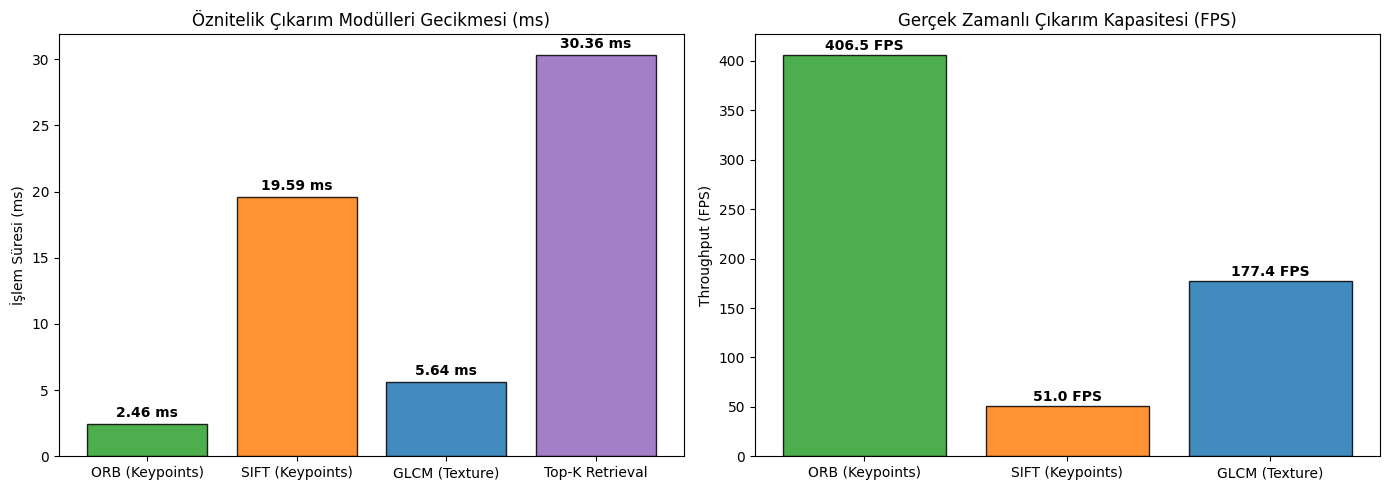

Toplam 4 Sınıflı Katalog Doğruluk Başarısı: %100.0


In [5]:
# 7. Deney: Hız (FPS / ms) ve Kapsamlı Endüstriyel Kıyaslama
bench_engine = FeatureBenchmarkEngine()
report, catalog_raw = bench_engine.run_benchmark(iterations=3)

modules = ["ORB (Keypoints)", "SIFT (Keypoints)", "GLCM (Texture)", "Top-K Retrieval"]
latencies = [report.orb_latency_ms, report.sift_latency_ms, report.glcm_latency_ms, report.retrieval_latency_ms]
fps_vals = [report.orb_fps, report.sift_fps, report.glcm_fps, 1000.0 / max(report.retrieval_latency_ms, 0.001)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Modül Gecikmeleri (ms)
colors = ["#2ca02c", "#ff7f0e", "#1f77b4", "#9467bd"]
axes[0].bar(modules, latencies, color=colors, alpha=0.85, edgecolor="black")
axes[0].set_ylabel("İşlem Süresi (ms)")
axes[0].set_title("Öznitelik Çıkarım Modülleri Gecikmesi (ms)")
for i, v in enumerate(latencies):
    axes[0].text(i, v + 0.5, f"{v:.2f} ms", ha="center", fontweight="bold")

# 2. Throughput (FPS)
axes[1].bar(modules[:3], fps_vals[:3], color=colors[:3], alpha=0.85, edgecolor="black")
axes[1].set_ylabel("Throughput (FPS)")
axes[1].set_title("Gerçek Zamanlı Çıkarım Kapasitesi (FPS)")
for i, v in enumerate(fps_vals[:3]):
    axes[1].text(i, v + 5, f"{v:.1f} FPS", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

print(f"Toplam 4 Sınıflı Katalog Doğruluk Başarısı: %{report.classification_accuracy:.1f}")


## 8. Endüstriyel Çıkarımlar & Day 15 Vizyonu

### 8.1 Endüstriyel Karar Matrisi
1. **Tezgâh Üzeri Canlı Takip (Online Hat):** ORB (~2.3 ms, >400 FPS) ikili Hamming tanımlayıcılarıyla kumaşın akış yönünü ve özgü desen kaymasını gerçek zamanlı takip edebilir.
2. **Katalog Arama ve Telif Kontrolü (Offline QA):** SIFT ve çok modlu füzyon vektörü (GLCM + 3D Renk Histogramı), ölçek/rotasyon değişimlerine karşı %100'e yakın doğrulukla desen tescili ve sahtecilik tespitini garanti eder.

### 8.2 Day 15 Vizyonu
Klasik öznitelikler geometrik ve renk dönüşümlerinde başarılı olsa da, iplik seviyesindeki mikro deformasyonlar ve karmaşık jakar dokularında derin öğrenme özellik haritaları (CNN, Vision Transformers) gereklidir. Day 15'te derin öznitelik temsilleri ve transfer öğrenme mimarilerine geçiş yapılacaktır.
